In [1]:
import sys
import torch

print("Python:", sys.version)
print("Executable:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Executable: O:\PYTHON\ai-gpu\Scripts\python.exe
PyTorch: 2.13.0+cu126
CUDA: 12.6
CUDA available: True
GPU: NVIDIA GeForce GTX 1650


In [2]:
import torch 
torch.__version__

'2.13.0+cu126'

In [3]:
torch.cuda.is_available()

True

In [4]:
tensor0d=torch.tensor(1)

tensor1d=torch.tensor([1,2,3])

tensor2d=torch.tensor([[1,2,3],[4,5,6]])

tensor3d=torch.tensor([[[1,2],[3,4]],[[5,6],[7,8]]])

In [5]:
print(tensor1d.dtype)

torch.int64


In [6]:
floatvec=torch.tensor([1.0,2.,3.])

In [7]:
print(floatvec.dtype)

torch.float32


In [9]:
newfloatvec=tensor1d.to(torch.float32)
print(newfloatvec.dtype)

torch.float32


In [ ]:
# Comprehensive coverage of all the different PyTorch tensor operations and commands is outside the scope of this tutorial
# However, we will briefly describe the essentials that you may require or stumble upon in almost any project.

In [12]:
print(f"{tensor0d}\n,{tensor1d}\n, {tensor2d}\n, {tensor3d}")

1
,tensor([1, 2, 3])
, tensor([[1, 2, 3],
        [4, 5, 6]])
, tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])


In [13]:
print(tensor2d.shape)

torch.Size([2, 3])


In [16]:
new_tensor2d=tensor2d.reshape(3,2)
print(new_tensor2d)

tensor([[1, 2],
        [3, 4],
        [5, 6]])


In [17]:
print(tensor2d.T)

tensor([[1, 4],
        [2, 5],
        [3, 6]])


In [18]:
tensor2d.matmul(tensor2d.T)
# matrix multiplication for tensor2d with its own transpose however this can be done in a better way using @

tensor([[14, 32],
        [32, 77]])

#  AUTOGRAD AND COMPUTATION GRAPH
# -A computational graph (or computation graph in short) is a directed graph that allows us to express and visualize mathematical expressions. 
# In the context of deep learning, a computation graph lays out the sequence of calculations needed to compute the output of a neural network
# – we will need this later to compute the required gradients for backpropagation, which is the main training algorithm for neural networks.

In [19]:
# LOGISTIC REGRESSION AS A SINGLE LAYER NEURAL NETWORK 
# FORWARD PASS

import torch.nn.functional as F

y=torch.tensor([1.0])
x1=torch.tensor([1.1])
w1=torch.tensor([2.2])
b=torch.tensor([0.0])

z=x1*w1+b

a=torch.sigmoid(z)

loss=F.binary_cross_entropy(a,y)
# the above is the forward pass for prediction and calculation of loss in prediction usinf the log regs log loss
print(loss)

tensor(0.0852)


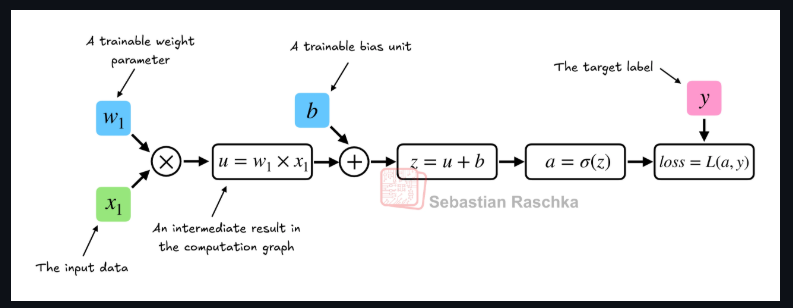

The above is the computational graph (forward pass) 

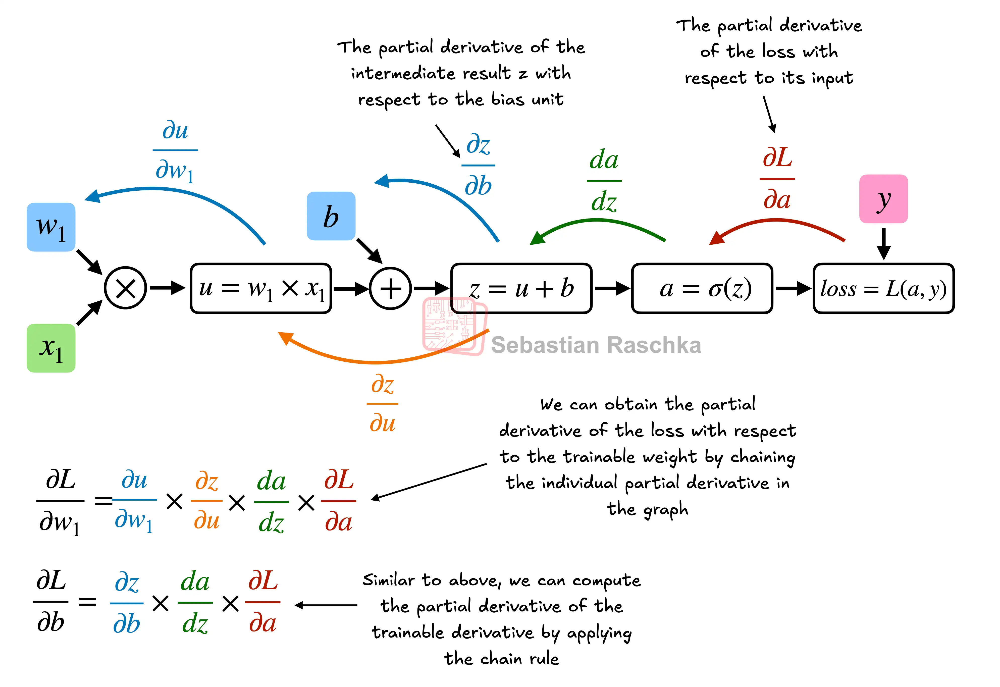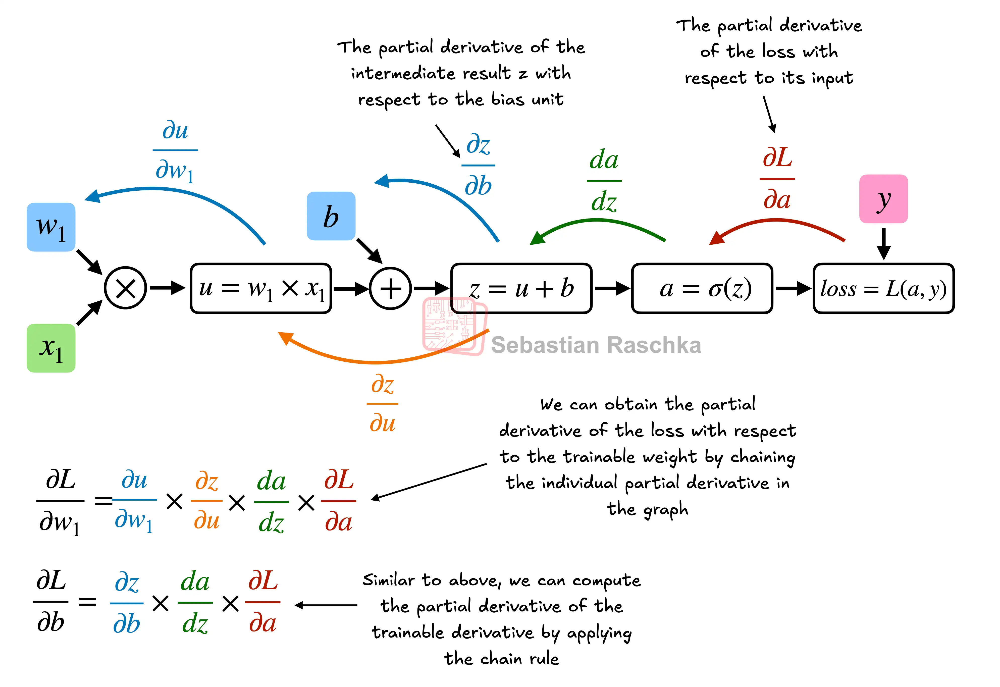

This is done to compute the gradient of the loss with respect to each parameter (weights and biases) in the network, which informs how we update these parameters during training.

# BACKPROPAGATION
By tracking every operation performed on tensors, PyTorch’s autograd engine constructs a computational graph in the background. Then, calling the grad function, we can compute the gradient of the loss with respect to model parameter w1 as follows:

In [23]:
from torch.autograd import grad 
y=torch.tensor([1.0])
x1=torch.tensor([1.1])
w1=torch.tensor([2.2],requires_grad=True)
b=torch.tensor([0.0],requires_grad=True)

z=x1*w1+b
a=torch.sigmoid(z)
loss=F.binary_cross_entropy(a,y)
grad_L_w1=grad(loss, w1, retain_graph=True)
grad_L_b=grad(loss, b , retain_graph=True)

By default, PyTorch destroys the computation graph after calculating the gradients to free memory. However, since we are going to reuse this computation graph shortly, we set retain_graph=True so that it stays in memory.

In [24]:
print(grad_L_w1)
print(grad_L_b)

(tensor([-0.0898]),)
(tensor([-0.0817]),)


Above, we have been using the grad function “manually,” which can be useful for experimentation, debugging, and demonstrating concepts. But in practice, PyTorch provides even more high-level tools to automate this process. For instance, we can call .backward on the loss, and PyTorch will compute the gradients of all the leaf nodes in the graph, which will be stored via the tensors’ .grad attributes:

In [25]:
loss.backward()

In [26]:
print(w1.grad)
print(b.grad)

tensor([-0.0898])
tensor([-0.0817])


# Implementing multilayer neural networks

In [44]:
# 3 layer MLP: 2 hidden + 1 output

class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()
        self.layers=torch.nn.Sequential(
            #1st hidden
            torch.nn.Linear(num_inputs,30),
            torch.nn.ReLU(),
           
            #2nd hidden
            torch.nn.Linear(30,20),
            torch.nn.ReLU(),

        # output_layer
        torch.nn.Linear(20,num_outputs)
        )

    def forward(self, x):
        logits=self.layers(x)
        return logits

In [45]:
model=NeuralNetwork(50,3)


In [46]:
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


In [47]:
num_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print("Total number of trainable model parameters:", num_params)

Total number of trainable model parameters: 2213


In [48]:
print(model.layers[0].weight)

Parameter containing:
tensor([[-0.0545, -0.0540, -0.0877,  ..., -0.1074,  0.0475, -0.0914],
        [ 0.0937,  0.0864, -0.1392,  ..., -0.0229, -0.0585, -0.0308],
        [-0.0272, -0.0924,  0.0747,  ...,  0.1139, -0.0028,  0.0376],
        ...,
        [-0.1097,  0.0503, -0.0334,  ...,  0.0722,  0.0249,  0.0851],
        [-0.0056, -0.1247, -0.0728,  ..., -0.1293,  0.0669,  0.0918],
        [-0.0777, -0.0145,  0.0640,  ..., -0.0041,  0.0554, -0.1172]],
       requires_grad=True)


In [49]:
print(model.layers[0].weight.shape)


torch.Size([30, 50])


In [50]:
print(model.layers[0].bias)

Parameter containing:
tensor([-0.0823,  0.0156,  0.0297,  0.1089, -0.0579, -0.0237, -0.0629,  0.0930,
         0.1272,  0.0442,  0.0042, -0.1122,  0.1123,  0.0844, -0.0669, -0.1258,
        -0.1146,  0.0941,  0.0842,  0.0776, -0.0344,  0.1401, -0.1004,  0.0418,
         0.0477, -0.0848,  0.0286,  0.1386, -0.0962, -0.0670],
       requires_grad=True)


In deep learning, initializing model weights with small random numbers is desired to break symmetry during training – otherwise, the nodes would be just performing the same operations and updates during backpropagation, which would not allow the network to learn complex mappings from inputs to outputs.

However, while we want to keep using small random numbers as initial values for our layer weights, we can make the random number initialization reproducible by seeding PyTorch’s random number generator via manual_seed:

In [51]:
torch.manual_seed(123)

model=NeuralNetwork(50,3)
print(model.layers[0].weight)

Parameter containing:
tensor([[-0.0577,  0.0047, -0.0702,  ...,  0.0222,  0.1260,  0.0865],
        [ 0.0502,  0.0307,  0.0333,  ...,  0.0951,  0.1134, -0.0297],
        [ 0.1077, -0.1108,  0.0122,  ...,  0.0108, -0.1049, -0.1063],
        ...,
        [-0.0787,  0.1259,  0.0803,  ...,  0.1218,  0.1303, -0.1351],
        [ 0.1359,  0.0175, -0.0673,  ...,  0.0674,  0.0676,  0.1058],
        [ 0.0790,  0.1343, -0.0293,  ...,  0.0344, -0.0971, -0.0509]],
       requires_grad=True)


In [53]:
torch.manual_seed(123)

X=torch.rand((1,50))
out=model(X)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]], grad_fn=<AddmmBackward0>)


In the code above, we generated a single random training example X as a toy input (note that our network expects 50-dimensional feature vectors) and fed it to the model, returning three scores. When we call model(x), it will automatically execute the forward pass of the model.

The forward pass refers to calculating output tensors from input tensors. This involves passing the input data through all the neural network layers, starting from the input layer, through hidden layers, and finally to the output layer.

These three numbers returned above correspond to a score assigned to each of the three output nodes. Notice that the output tensor also includes a grad_fn value.

Here, grad_fn=<AddmmBackward0> represents the last-used function to compute a variable in the computational graph. In particular, grad_fn=<AddmmBackward0> means that the tensor we are inspecting was created via a matrix multiplication and addition operation. PyTorch will use this information when it computes gradients during backpropagation. The <AddmmBackward0> part of grad_fn=<AddmmBackward0> specifies the operation that was performed. In this case, it is an Addmm operation. Addmm stands for matrix multiplication (mm) followed by an addition (Add).

If we just want to use a network without training or backpropagation, for example, if we use it for prediction after training, constructing this computational graph for backpropagation can be wasteful as it performs unnecessary computations and consumes additional memory. So, when we use a model for inference (for instance, making predictions) rather than training, it is a best practice to use the torch.no_grad() context manager, as shown below

In [55]:
with torch.no_grad():
    out = model(X)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]])


In PyTorch, it’s common practice to code models such that they return the outputs of the last layer (logits) without passing them to a nonlinear activation function. That’s because PyTorch’s commonly used loss functions combine the softmax (or sigmoid for binary classification) operation with the negative log-likelihood loss in a single class.

In [56]:
with torch.no_grad():
    out = torch.softmax(model(X), dim=1)
print(out)

tensor([[0.3113, 0.3934, 0.2952]])


# Setting up efficient data loaders 

Before we can train this model, we have to briefly talk about creating efficient data loaders in PyTorch, which we will iterate over when training the model.
## Epochs
Figure 10. PyTorch implements a `Dataset` and a `DataLoader` class. The `Dataset` class is used to instantiate objects that define how each data record is loaded. The `DataLoader` handles how the data is shuffled and assembled into batches.
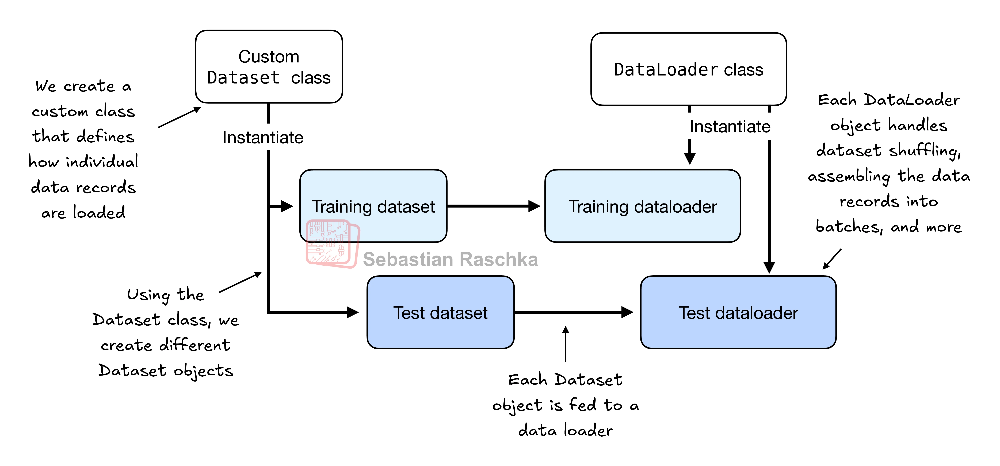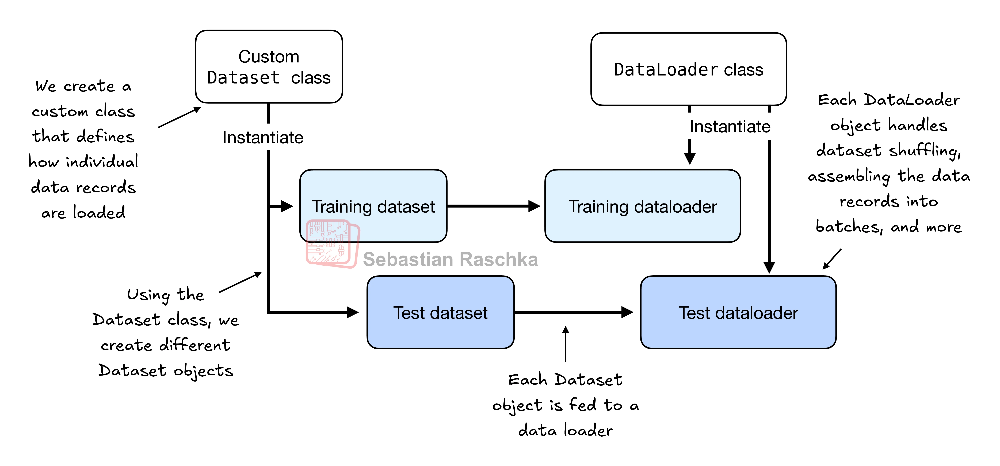

In [58]:
X_train = torch.tensor([
    [-1.2, 3.1],
    [-0.9, 2.9],
    [-0.5, 2.6],
    [2.3, -1.1],
    [2.7, -1.5]
])

y_train = torch.tensor([0, 0, 0, 1, 1])

In [59]:
X_test = torch.tensor([
    [-0.8, 2.8],
    [2.6, -1.6],
])

y_test = torch.tensor([0, 1])

Class label numbering PyTorch requires that class labels start with label 0, and the largest class label value should not exceed the number of output nodes minus 1 (since Python index counting starts at 0. So, if we have class labels 0, 1, 2, 3, and 4, the neural network output layer should consist of 5 nodes.

In [71]:
from torch.utils.data import Dataset

class ToyDataset(Dataset):
    def __init__(self,X, y):
        self.features=X
        self.labels=y

    def __getitem__(self,index):
        one_x=self.features[index]
        one_y=self.labels[index]
        return one_x,one_y

    def __len__(self):
        return self.labels.shape[0]

train_ds=ToyDataset(X_train,y_train)
test_ds=ToyDataset(X_test,y_test)
    

In PyTorch, the three main components of a custom Dataset class are the __init__ constructor, the __getitem__ method, and the __len__ method, as shown in code ToyDataset code above.

In the __init__ method, we set up attributes that we can access later in the __getitem__ and __len__ methods. This could be file paths, file objects, database connectors, and so on. Since we created a tensor dataset that sits in memory, we are simply assigning X and y to these attributes, which are placeholders for our tensor objects.

In the __getitem__ method, we define instructions for returning exactly one item from the dataset via an index. This means the features and the class label corresponding to a single training example or test instance. (The data loader will provide this index, which we will cover shortly.)

Finally, the __len__ method contains instructions for retrieving the length of the dataset. Here, we use the .shape attribute of a tensor to return the number of rows in the feature array. In the case of the training dataset, we have five rows, which we can double-check as follows:

In [72]:
len(train_ds)

5

In [73]:
len(test_ds)

2

Now that we defined a PyTorch Dataset class we can use for our toy dataset, we can use PyTorch’s DataLoader class to sample from it, as shown in the code below:

In [82]:
from torch.utils.data import DataLoader

torch.manual_seed(123)

train_loader=DataLoader(dataset=train_ds,
                        batch_size=2,
                        shuffle=True,
                        num_workers=0)

In [83]:
test_ds=ToyDataset(X_test, y_test)

test_loader=DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0)

In [84]:
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)

Batch 1: tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])
Batch 2: tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 3: tensor([[ 2.7000, -1.5000]]) tensor([1])


As we can see based on the output above, the train_loader iterates over the training dataset visiting each training example exactly once. This is known as a training epoch. Since we seeded the random number generator using torch.manual_seed(123) above, you should get the exact same shuffling order of training examples as shown above. However if you iterate over the dataset a second time, you will see that the shuffling order will change. This is desired to prevent deep neural networks getting caught in repetitive update cycles during training.

Note that we specified a batch size of 2 above, but the 3rd batch only contains a single example. That’s because we have five training examples, which is not evenly divisible by 2. In practice, having a substantially smaller batch as the last batch in a training epoch can disturb the convergence during training. To prevent this, it’s recommended to set drop_last=True, which will drop the last batch in each epoch, as shown below:

In [85]:
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

In [86]:
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)

Batch 1: tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 2: tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])


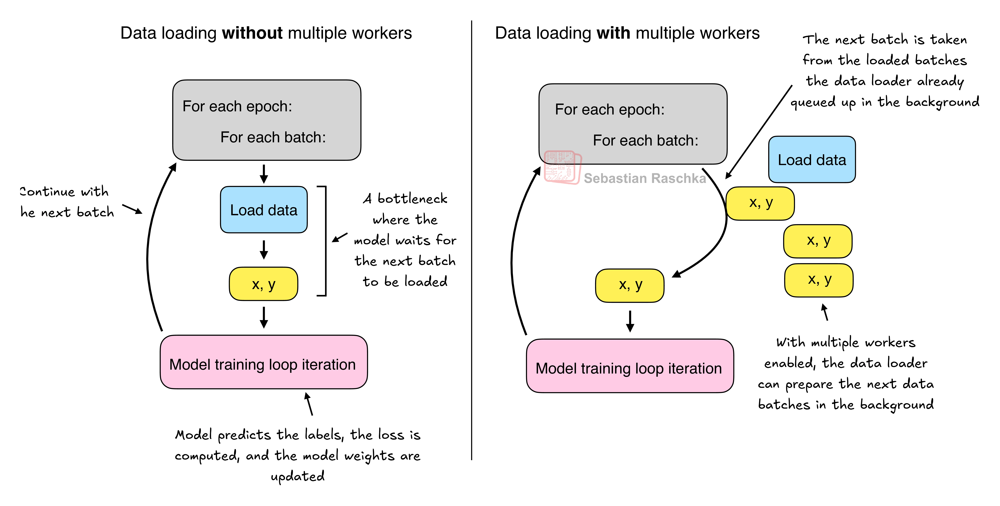

For very small datasets, num_workers > 0 usually provides little or no speedup because worker-process startup overhead can outweigh data-loading time. In Jupyter, multiple workers can also cause resource-sharing issues or crashes. Therefore, num_workers should be chosen based on dataset size, hardware, and the Dataset implementation; num_workers=4 is a common starting point for larger workloads but is not universally optimal.

# A typical training loop 

In [88]:
import torch.nn.functional as F

torch.manual_seed(123)

model=NeuralNetwork(num_inputs=2,num_outputs=2)
optimizer = torch.optim.SGD(model.parameters(),lr=0.5)

num_epochs=3

for epoch in range(num_epochs):
    model.train()
    for batch_idx , (features, labels) in enumerate(train_loader):
        logits=model(features)
        loss=F.cross_entropy(logits,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
              f" | Train/Val Loss: {loss:.2f}")
        
        model.eval()


Epoch: 001/003 | Batch 000/002 | Train/Val Loss: 0.75
Epoch: 001/003 | Batch 001/002 | Train/Val Loss: 0.65
Epoch: 002/003 | Batch 000/002 | Train/Val Loss: 0.44
Epoch: 002/003 | Batch 001/002 | Train/Val Loss: 0.13
Epoch: 003/003 | Batch 000/002 | Train/Val Loss: 0.03
Epoch: 003/003 | Batch 001/002 | Train/Val Loss: 0.00


### PyTorch Training Loop — Quick Notes

- `model = NeuralNetwork(2, 2)` → 2 input features, 2 output classes.
- `SGD(lr=0.5)` → optimizer; `lr` controls the step size of weight updates.
- `num_epochs=3` → number of complete passes over the training data.
- `model.train()` → training mode; important for Dropout/BatchNorm.
- `logits = model(features)` → forward pass; produces raw class scores.
- `F.cross_entropy(logits, labels)` → calculates classification loss; internally applies softmax/log-softmax.
- `optimizer.zero_grad()` → clears accumulated gradients.
- `loss.backward()` → backpropagation; computes gradients of the loss w.r.t. parameters.
- `optimizer.step()` → updates parameters using the gradients:
 $$
\boxed{w_{\text{new}} = w_{\text{old}} - \eta \frac{\partial L}{\partial w}}
$$
- `model.eval()` → evaluation mode; affects layers such as Dropout/BatchNorm.
- **Training cycle:** `forward → loss → zero_grad → backward → step`
- **Hyperparameters:** learning rate, epochs, batch size.
- **Validation set** → used repeatedly for hyperparameter tuning.
- **Test set** → ideally used only once for final unbiased evaluation.

In [89]:
with torch.no_grad():
    outputs=model(X_train)

print(outputs)

tensor([[ 2.8569, -4.1618],
        [ 2.5382, -3.7548],
        [ 2.0944, -3.1820],
        [-1.4814,  1.4816],
        [-1.7176,  1.7342]])


To obtain the class membership probabilities, we can then use PyTorch’s softmax function, as follows:

In [90]:
torch.set_printoptions(sci_mode=False)
probas = torch.softmax(outputs, dim=1)
print(probas)

tensor([[0.9991, 0.0009],
        [0.9982, 0.0018],
        [0.9949, 0.0051],
        [0.0491, 0.9509],
        [0.0307, 0.9693]])


Let’s consider the first row in the code output above. Here, the first value (column) means that the training example has a 99.91% probability of belonging to class 0 and a 0.09% probability of belonging to class 1. (The set_printoptions call is used here to make the outputs more legible.)

We can convert these values into class labels predictions using PyTorch’s argmax function, which returns the index position of the highest value in each row if we set dim=1 (setting dim=0 would return the highest value in each column, instead):

In [91]:
predictions = torch.argmax(probas, dim=1)
print(predictions)

tensor([0, 0, 0, 1, 1])


In [92]:
# Note that it is unnecessary to compute softmax probabilities 
# to obtain the class labels. We could also apply the argmax function
# to the logits (outputs) directly:

predictions = torch.argmax(outputs, dim=1)
print(predictions)

tensor([0, 0, 0, 1, 1])


In [95]:
def compute_accuracy(model,dataloader):
    model.eval()
    correct=0.0
    total_examples=0

    for idx, (features,labels) in enumerate(dataloader):
        with torch.no_grad():
            logits=model(features)

        predictions=torch.argmax(logits,dim=1)
        compare=(labels==predictions)
        correct+=torch.sum(compare)
        total_examples+=len(compare)
    return (correct / total_examples).item()


Note that the following compute_accuracy function iterates over a data loader to compute the number and fraction of the correct predictions. This is because when we work with large datasets, we typically can only call the model on a small part of the dataset due to memory limitations. The compute_accuracy function above is a general method that scales to datasets of arbitrary size since, in each iteration, the dataset chunk that the model receives is the same size as the batch size seen during training.

Notice that the internals of the compute_accuracy function are similar to what we used before when we converted the logits to the class labels.

In [96]:
compute_accuracy(model, train_loader)

1.0

# Saving and loading models 

In [98]:
torch.save(model.state_dict(), "model.pth")

The model’s state_dict is a Python dictionary object that maps each layer in the model to its trainable parameters (weights and biases). Note that "model.pth" is an arbitrary filename for the model file saved to disk. We can give it any name and file ending we like; however, .pth and .pt are the most common conventions

In [99]:
model = NeuralNetwork(2, 2) # needs to match the original model exactly
model.load_state_dict(torch.load("model.pth", weights_only=True))


<All keys matched successfully>

The torch.load("model.pth") function reads the file "model.pth" and reconstructs the Python dictionary object containing the model’s parameters while model.load_state_dict() applies these parameters to the model, effectively restoring its learned state from when we saved it.

Note that the line model = NeuralNetwork(2, 2) above is not strictly necessary if you execute this code in the same session where you saved a model. However, I included it here to illustrate that we need an instance of the model in memory to apply the saved parameters. Here, the NeuralNetwork(2, 2) architecture needs to match the original saved model exactly.

In [100]:
print(torch.cuda.is_available())

True


In [103]:
tensor_1=torch.tensor([1.,2.,3.])
tensor_2=torch.tensor([4.,5.,6.])

print(tensor_1+tensor_2)

tensor([5., 7., 9.])


In [104]:
tensor_1=tensor_1.to("cuda")
tensor_2=tensor_2.to("cuda")

print(tensor_1+tensor_2)

tensor([5., 7., 9.], device='cuda:0')


Notice that the resulting tensor now includes the device information, device='cuda:0', which means that the tensors reside on the first GPU. If your machine hosts multiple GPUs, you have the option to specify which GPU you’d like to transfer the tensors to

However, it is important to note that all tensors must be on the same device. Otherwise, the computation will fail, as shown below, where one tensor resides on the CPU and the other on the GPU:

In [107]:
tensor_1 = tensor_1.to("cpu")
print(tensor_1 + tensor_2)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

# Single-GPU training 

In [109]:
torch.manual_seed(123)
model=NeuralNetwork(num_inputs=2,num_outputs=2)

device=torch.device("cuda")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model.to(device)

optimizer=torch.optim.SGD(model.parameters(),lr=0.5)

num_epochs=3

for epoch in range(num_epochs):
    model.train()
    for batch_idx,(features, labels) in enumerate(train_loader):
          # New: Transfer the data onto the GPU.
        features,labels=features.to(device),labels.to(device)
        logits=model(features)
        loss=F.cross_entropy(logits, labels) #loss function

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
              f" | Train/Val Loss: {loss:.2f}")


    model.eval()

        

Epoch: 001/003 | Batch 000/002 | Train/Val Loss: 0.75
Epoch: 001/003 | Batch 001/002 | Train/Val Loss: 0.65
Epoch: 002/003 | Batch 000/002 | Train/Val Loss: 0.44
Epoch: 002/003 | Batch 001/002 | Train/Val Loss: 0.13
Epoch: 003/003 | Batch 000/002 | Train/Val Loss: 0.03
Epoch: 003/003 | Batch 001/002 | Train/Val Loss: 0.00


# Training with multiple GPUs 

In this section, we will briefly go over the concept of distributed training. Distributed training is the concept of dividing the model training across multiple GPUs and machines.

In this section, we will look at the most basic case of distributed training: PyTorch’s DistributedDataParallel (DDP) strategy. DDP enables parallelism by splitting the input data across the available devices and processing these data subsets simultaneously.

How does this work? PyTorch launches a separate process on each GPU, and each process receives and keeps a copy of the model – these copies will be synchronized during training

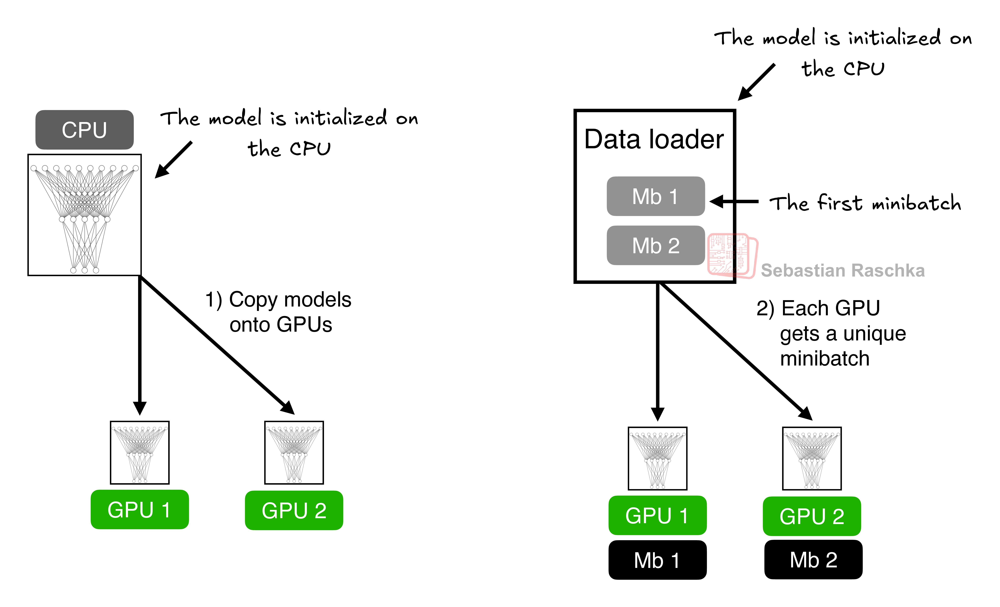

Each of the two GPUs will receive a copy of the model. Then, in every training iteration, each model will receive a minibatch (or just batch) from the data loader. We can use a DistributedSampler to ensure that each GPU will receive a different, non-overlapping batch when using DDP.

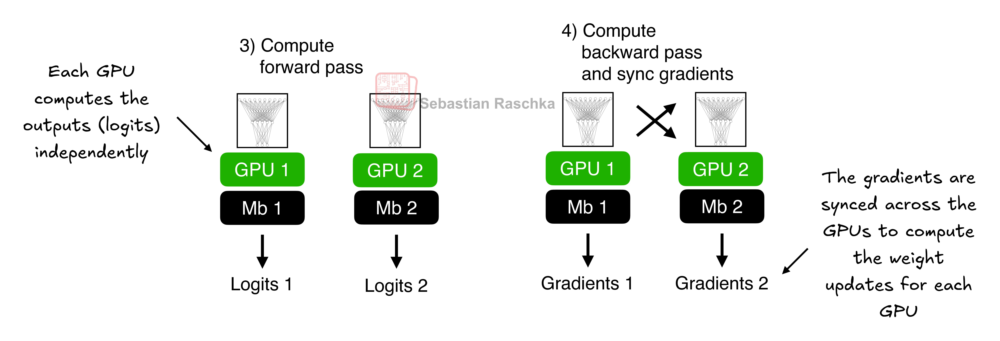

The benefit of using DDP is the enhanced speed it offers for processing the dataset compared to a single GPU. Barring a minor communication overhead between devices that comes with DDP use, it can theoretically process a training epoch in half the time with two GPUs compared to just one. 

Multi-GPU computing in interactive environments DDP does not function properly within interactive Python environments like Jupyter notebooks, which don’t handle multiprocessing in the same way a standalone Python script does. Therefore, the following code should be executed as a script, not within a notebook interface like Jupyter. This is because DDP needs to spawn multiple processes, and each process should have its own Python interpreter instance.

link - https://sebastianraschka.com/teaching/pytorch-1h/